# Setup

In [763]:
# auto reload modules
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import copy as copy
import time as tpy
import pandas as pd
from scipy import stats,signal, fft
from scipy.stats import norm,wilcoxon,pearsonr 
import sys, os
import sys
import figurefirst as fifi
from IPython.display import display,SVG
from globalVars import *
from load_data import *
from analysis import mean_and_interquartile,WilcoxonTest
from collect_data import findFilename, getrawdata, get_data, analyze
import plotting_variables
from plotting_variables import TINY_SIZE, SMALL_SIZE, MEDIUM_SIZE, BIGGER_SIZE, MARKER_SIZE, python_colors, colors, yfill, ufill, gfill, rfill, bfill
from matplotlib.colors import to_rgba
from matplotlib.transforms import blended_transform_factory

print('data length = ',N)
print('primes = ',primes)
print('base freq = ',base_freq)
print('IX = ',IX)
print('freqs = ',freqs)
print('omegas = ',omegas)
print('T = ',T) # total time 40 seconds
print('t = ',t) # timestamps
print('fs = ',fs)
print('sample_period (dt)= ',dt)
print('xf = ',xf) # frequency domain x-axis, shape (N//2,)
print('s = ',s)
print('z = ',z)
print('soM = ',soM)
print('zero = ',zero)
print('first = ',first)
print('second = ',second)

print('subject_num = ',subject_num)
print('condition_num (orders) = ',condition_num)
print('trial_num = ',trial_num)
print('trial_num of baseline = ',trial_num_base)
print('\n')

# interface transfer function parameters (subjects x trials x number of parameters)
print('0th-order interface parameters, G_parameters shape= ',G_parameters[0].shape)
print('1st-order interface parameters, G_parameters shape= ',G_parameters[1].shape)
print('2nd-order interface parameters, G_parameters shape= ',G_parameters[2].shape)
# print(G_parameters[0].shape,G_parameters[1].shape,G_parameters[2].shape) 
print('\n')

# freqeuncy domain signals
print('Interface transfer function, Gs shape=', Gs.shape) # interface transfer function (subjects x condition x trials x stim frequencies)
print('Human transfer function, Hs shape=',Hs.shape) # human transfer function (subjects x condition x trials x stim frequencies)
print('Disturbance signals, Ds shape=', Ds.shape) # disturbances (subjects x condition x trials x number of frequencies)
print('Human inputs signals, UHs shape=', UHs.shape) # human inputs (subjects x condition x trials x number of frequencies)
print('Interface inputs signals, UIs shape=', UGs.shape) # interface inputs (subjects x condition x trials x number of frequencies)
print('Output signals, Ys shape=', Ys.shape) # output (subjects x condition x trials x number of frequencies)
print('\n')
print('Baseline interface transfer function, Gs_base shape=', Gs_base.shape) # interface transfer function (subjects x trials x stim frequencies)
print('\n')

# time domain signals
print('time-domain disturbances, ds shape=', ds.shape) # disturbances (subjects x condition x trials x number of time points)
print('time-domain human inputs, uhs shape=', uhs.shape) # human inputs (subjects x condition x trials x number of time points)
print('time-domain interface inputs, ugs shape=', ugs.shape) # interface inputs (subjects x condition x trials x number of time points)
print('time-domain outputs, ys shape=', ys.shape) # output (subjects x condition x trials x number of time points)
print('time-domain MSE per trial, errors shape=',errors.shape) # errors (subjects x condition x trials) #np.sum(abs(outs)**2)
print('\n')

# continuous M IS -2(s-2.2)/(s^2+3.6s+4)
M = -2*(s(omegas)-2.2)/(s(omegas)**2+3.6*s(omegas)+4)

soM_ = lambda s : 1/(s**2 + s)      #2nd order machine in multimodal exp 
M_other = soM_(s(omegas))           #M_hat = 1/ ((jw)^2 + (jw)) at stimulated frequencies
# check M and soM
# plt.figure(figsize=(3,2))
# plt.plot(np.abs(soM),'-o',label='soM (discrete)')
# plt.plot(np.abs(M),'-o',label='M (continous)')
# # plt.plot(np.abs(M_other),'-o',label='M other exp (continous)')
# plt.xlabel('stim freqs')
# plt.legend()
# plt.show()

# initial interfaces (I stars) for each condition
I_star_0 = Gs[0,0,0]
I_star_1 = Gs[0,1,0]
I_star_2 = Gs[0,2,0]
I_stars = [I_star_0,I_star_1,I_star_2]

# Loop Transfer functions (empirical data) 3 conditions
HMIs = Hs[:,:,:,IX]*soM*Gs # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HMIs.shape)
HMs = Hs[:,:,:,IX]*soM # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HMs.shape)
HIs = Hs[:,:,:,IX]*Gs # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HIs.shape)

# Loop Transfer functions (empirical data) baseline (passthrough interface)
HMIs_base = Hs_base[:,:,IX]*soM # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough
print(HMIs_base.shape)
HMs_base = Hs_base[:,:,IX]*soM # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough
print(HMs_base.shape)
HIs_base = Hs_base[:,:,IX] # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough 
print(HIs_base.shape)

lowest_x_freq = 8 # lowest ? stimulated frequency for the analysis

# frequency domain output at stimulated frequencies
Y_norm = np.linalg.norm(Ys[:,:,:,IX[:lowest_x_freq]],axis = 3) # across timesteps, one number per trial
Y_base_norm = np.linalg.norm(Ys_base[:,:,IX[:lowest_x_freq]],axis = 2) # across timesteps, one number per trial
print(Y_norm.shape),print(Y_base_norm.shape)

# human input for each trial ||u_H||2
UH_norm = np.linalg.norm(UHs[:,:,:,IX[:lowest_x_freq]],axis = 3)
UH_base_norm = np.linalg.norm(UHs_base[:,:,IX[:lowest_x_freq]],axis = 2)
# print(uH_norm.shape),print(uH_base_norm.shape)

# interface input for each trial ||u_I||2
UI_norm = np.linalg.norm(UGs[:,:,:,:lowest_x_freq],axis = 3) # already at the stimulated freq
UI_base_norm = np.linalg.norm(UGs_base[:,:,:lowest_x_freq],axis = 2)

# freq-domain interface loss 
lamH = 1.5 #Hyperparameter for tradeoff between interface effort and human effort
lamG = 0.5
D_norm = np.linalg.norm(np.asarray(Ds[:,:,:,IX[:lowest_x_freq]]),axis = 3)
D_norm_base = np.linalg.norm(np.asarray(Ds_base[:,:,IX[:lowest_x_freq]]),axis = 2)
interface_loss_freqdomain = (Y_norm + lamH*UH_norm + lamG*UI_norm) / D_norm
print(interface_loss_freqdomain.shape)
interface_loss_freqdomain_base = (Y_base_norm + lamH*UH_base_norm + lamG*UI_base_norm) / D_norm_base
print(interface_loss_freqdomain_base.shape)

# freq-domain human loss
HlamH = 1.5
human_loss_freqdomain = (Y_norm + HlamH*UH_norm) / D_norm
human_loss_freqdomain_base = (Y_base_norm + HlamH*UH_base_norm) / D_norm_base


def plot_stats_lines(d1, d2, ax, bplot, box_x, i1, i2, level=0, *, y0, h, lw=0.5, print_ns=False):
    """Paired t-test between d1 and d2; bracket between box indices i1 and i2 (into box_x)."""
    _, p = stats.ttest_rel(d1, d2)
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    if sig == 'ns' and not print_ns:
        return float('-inf')
    x1, x2 = box_x[i1], box_x[i2]
    ax.plot(
        [x1, x1, x2, x2],
        [y0, y0 + h, y0 + h, y0],
        color='black',
        lw=lw,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y0 + h,
        sig,
        ha='center',
        va='bottom',
        fontsize=SMALL_SIZE if sig in ('*', '**', '***') else TINY_SIZE,
        fontweight='bold' if sig in ('*', '**', '***') else 'normal',
        clip_on=False,
    )
    return y0 + h



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
data length =  2400
primes =  [ 2  3  5  7 11 13 17 19]
base freq =  0.05
IX =  [ 4  6 10 14 22 26 34 38]
freqs =  [0.1  0.15 0.25 0.35 0.55 0.65 0.85 0.95]
omegas =  [0.62831853 0.9424778  1.57079633 2.19911486 3.45575192 4.08407045
 5.34070751 5.96902604]
T =  40
t =  [0.00000000e+00 1.66736140e-02 3.33472280e-02 ... 3.99666528e+01
 3.99833264e+01 4.00000000e+01]
fs =  60
sample_period (dt)=  0.016666666666666666
xf =  [0.0000e+00 2.5000e-02 5.0000e-02 ... 2.9925e+01 2.9950e+01 2.9975e+01]
s =  <function <lambda> at 0x161db2160>
z =  <function <lambda> at 0x162264720>
soM =  [ 0.71461011-0.8032687j   0.33652234-0.98372476j -0.33237591-0.86073923j
 -0.6163471 -0.48027949j -0.55477368+0.01684599j -0.46273241+0.11912274j
 -0.31404983+0.19698778j -0.26054454+0.2069847j ]
zero =  <function zero at 0x162264860>
first =  <function first at 0x162492a20>
second =  <function second at 0x1624934c0>
subject_n

In [764]:
zero_order_Gs.shape, first_order_Gs.shape, second_order_Gs.shape

((100,), (3, 8546), (5, 87038))

In [765]:
# # load pickle
# with open('HCPS097_107_H_model_fitting.pkl', 'rb') as file:
#     H_2nd_params, H_2nd_fits, H_2nd_params_base, H_2nd_fits_base = pickle.load(file)

with open('20260512_model_fit_data.pkl', 'rb') as file:
    H_2nd_params, H_2nd_fits, H_2nd_params_base, H_2nd_fits_base, H_1st_params, H_1st_fits, H_1st_params_base, H_1st_fits_base = pickle.load(file)

In [766]:
# load pickle file
with open('simulated_results_sweep_lambda.pkl', 'rb') as f:
    Hs_sim_parameters_1st, Hs_sim_1st, Gs_sim_parameters_1st, Gs_sim_1st, time_domain_y, time_domain_uH, time_domain_uG, freq_domain_Y, freq_domain_UH, freq_domain_UG, freq_domain_D, best_triple = pickle.load(f)

N_trial = 15

# Figures

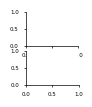

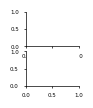

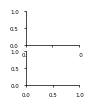

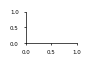

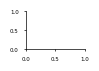

In [767]:
lo = fifi.FigureLayout('fig5_template.svg', autogenlayers=True, make_mplfigures=True, hide_layers=['Layer 1'])
lo.apply_mpl_methods() 
lo.clear_fflayer('mpl_layer') 

# Fig A model fitting

In [768]:
# set up figures
axs = np.empty(2, dtype=object)
axs[0] = lo.axes[('fig5A','A1')]
axs[1] = lo.axes[('fig5A','A2')]

In [769]:
# plot interface
xlim = (0.095, 1.0)
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
ylimphase = (-np.pi/2,np.pi+1)
yticksphase = [-np.pi/2,0.,np.pi]
yticklabelsphase = [r'$-\frac{\pi}{2}$', r'$0$',r'$+\pi$']

cond = 1
ax = axs[0]
H_last_3_trials = np.mean(np.abs(-H_2nd_fits[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials  # invert H to match paper figure
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0) # mean across subjects
ax.plot(freqs,quantile50,'--',marker = '.',color = 'grey',alpha=1,label = r'$H_\text{fit (2nd-order)}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'grey',edgecolor='none')

# overlay exp result
H_last_3_trials = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'red',alpha=1,label = r'$H_\text{exp}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red',edgecolor='none')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels([]) 
ax.set_ylabel('magnitude')
ax.set_title('model fit')
ax.tick_params(axis='y')

ax = axs[1]
H_last_3_trials = np.mean(np.angle(-H_2nd_fits[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0) # mean across subjects
ax.plot(freqs,quantile50,'--',marker = '.',color = 'grey',alpha=1,label = r'$H_\text{fit}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'grey',edgecolor='none')

# # overlay exp result
H_last_3_trials = np.mean(np.angle(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials 
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'red',alpha=1, label = r'$H_\text{exp}$')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red',edgecolor='none')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks,rotation=90, fontsize=TINY_SIZE-1) 
ax.set_ylabel('phase') 
ax.set_xlabel('frequency (Hz)')
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)

for ax in axs:
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.tick_params(direction="in")

axs[0].legend(loc='upper left',frameon = False,ncol = 1)

In [770]:
H_2nd_fits[:,cond,15:18,:].shape

(11, 3, 8)

In [771]:
# coorelation between model and empirical
H_last_3_trials_fit = np.mean(np.abs(-H_2nd_fits[:,cond,15:18,:]),axis = 1) 
H_last_3_trials_emp = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1)
for f in range(8):
    corr, p_value = pearsonr(H_last_3_trials_fit[:,f], H_last_3_trials_emp[:,f])
    print(f"Correlation: {corr}, P-value: {p_value}")

print('\n')

# coorelation between model and empirical
H_last_3_trials_fit = np.mean(np.abs(-H_1st_fits[:,cond,15:18,:]),axis = 1) 
H_last_3_trials_emp = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1)
for f in range(8):
    corr, p_value = pearsonr(H_last_3_trials_fit[:,f], H_last_3_trials_emp[:,f])
    print(f"Correlation: {corr}, P-value: {p_value}")

Correlation: 0.9776303080801207, P-value: 2.1228332343797546e-07
Correlation: 0.9517854993047241, P-value: 6.4782771190450935e-06
Correlation: 0.9032266656802724, P-value: 0.0001386838281942654
Correlation: 0.88008035078208, P-value: 0.0003516688558712945
Correlation: 0.9909818434518218, P-value: 3.6293365209848913e-09
Correlation: 0.9559023068795793, P-value: 4.3615037208199275e-06
Correlation: 0.9796335038270967, P-value: 1.3958057447453578e-07
Correlation: 0.9971053763310962, P-value: 2.2018010188869258e-11


Correlation: 0.7725609116925767, P-value: 0.005315583290689009
Correlation: 0.8155452537544137, P-value: 0.002213588895747079
Correlation: 0.8064162787508936, P-value: 0.0027126788391013505
Correlation: 0.8655124387696304, P-value: 0.0005763528912021303
Correlation: 0.9584572116502947, P-value: 3.346645812029802e-06
Correlation: 0.9884191608448227, P-value: 1.114365585990033e-08
Correlation: 0.9480640697887842, P-value: 9.003418445836819e-06
Correlation: 0.9379192058853545, P-v

# Fig B

In [772]:
# set up figures
axs = np.empty(2, dtype=object)
axs[0] = lo.axes[('fig5B','B1')]
axs[1] = lo.axes[('fig5B','B2')]

In [773]:
# Bode plot parameters
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
increment_alpha = np.linspace(0.1,0.3,N_trial+1)
ylimphase = (-np.pi/2,np.pi+1)
yticksphase = [-np.pi/2,0.,np.pi]
yticklabelsphase = [r'$-\frac{\pi}{2}$', r'$0$',r'$+\pi$']
final_trial_idx = 17
cond = 1
ax = axs[0]
# overlay exp result
G_last_3_trials = np.mean(np.abs(Gs[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials 
for sub in range(subject_num):
    ax.plot(freqs, G_last_3_trials[sub],'-',marker = '.',color = 'blue',alpha=0.5) # last adaptive trial of the experiment
# for trial in range(N_trial):
#     ax.plot(freqs,np.abs(Gs_sim_1st[trial,:]),'-',marker = '.',color = 'black',alpha=increment_alpha[trial])
ax.plot(freqs,np.abs(Gs_sim_1st[-1,:]),'-',marker = '.',color = 'black',alpha=1, label = r'$I_\mathrm{sim}$')
ax.plot([],[],color = 'blue',marker = '.',label = r'$I_\mathrm{exp}$')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels([]) 
ax.set_ylabel('magnitude')
ax.set_title('simulation')
ax.tick_params(axis='y')


ax = axs[1]
# overlay exp result
G_last_3_trials = np.mean(np.angle(Gs[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials 
for sub in range(subject_num):
    ax.plot(freqs, G_last_3_trials[sub],'-',marker = '.',color = 'blue',alpha=0.5) # last adaptive trial of the experiment
# for trial in range(N_trial):
#     ax.plot(freqs,np.angle(Gs_sim_1st[trial,:]),'-',marker = '.',color = 'black',alpha=increment_alpha[trial])
ax.plot(freqs,np.angle(Gs_sim_1st[-1,:]),'-',marker = '.',color = 'black',alpha=1, label = r'$I_\mathrm{sim}$')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks,rotation=90, fontsize=TINY_SIZE-1) 
ax.set_ylabel('phase') 
ax.set_xlabel('frequency (Hz)')
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)

for ax in axs:
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.tick_params(direction="in")


# axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon = False )
axs[0].legend(loc='upper left',frameon = False,ncol = 1)

# mean and std

In [774]:
# difference between simulated final and experimental (in magnitudes)
final_trial_idx = 17
for f in range(8):
    G_last_3_trials = np.mean(np.abs(Gs[:,cond,15:18,:]),axis = 1) # avg last 3 adaptive trials 
    mean_emp = np.mean(G_last_3_trials[:,f]) # mean of subjects
    std_emp = np.std(G_last_3_trials[:,f])

    simulated_final = np.abs(Gs_sim_1st[-1,f])
    # difference from mean of subjects
    diff = simulated_final - mean_emp
    # z-score relative to sample SD
    z_score = np.abs(diff / std_emp)

    print(f"z-score: {z_score}")
    # print(f"Difference: {np.mean(diff)}, Std: {np.std(diff)}")


z-score: 0.29129582915302676
z-score: 0.09027983056865141
z-score: 0.2974486341629909
z-score: 0.4854601515242804
z-score: 0.6133569301992181
z-score: 0.637757694015664
z-score: 0.6624967694239627
z-score: 0.6691925992548893


# Fig C

In [775]:
# set up figures
axs = np.empty(2, dtype=object)
axs[0] = lo.axes[('fig5C','C1')]
axs[1] = lo.axes[('fig5C','C2')]

In [776]:
# plot interface
ylimphase = (-np.pi/2,np.pi+1)
yticksphase = [-np.pi/2,0.,np.pi]
yticklabelsphase = [r'$-\frac{\pi}{2}$', r'$0$',r'$+\pi$']

cond = 1
condition = 'first'
ax = axs[0]
final_trial_idx = 17
# overlay exp result
H_last_3_trials = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials 
for sub in range(subject_num):
    ax.plot(freqs, H_last_3_trials[sub],'-',marker = '.',color = 'red',alpha=0.5) # last adaptive trial of the experiment
# for trial in range(N_trial):
#     ax.plot(freqs,np.abs(Hs_sim_1st[trial,:]),'-',marker = '.',color = 'black',alpha=increment_alpha[trial])
ax.plot(freqs,np.abs(-Hs_sim_1st[-1,:]),'-',marker = '.',color = 'black',alpha=1, label = r'$H_\mathrm{sim}$')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels([]) 
ax.plot([],[],color = 'red',marker = '.',label = r'$H_\mathrm{exp}$')
ax.tick_params(axis='y')


ax = axs[1]
# overlay exp result # fix the circularity of the phase plot
ph = np.mean(np.exp(1j*(np.angle(-Hs[:,cond,15:18,:][:,:,IX])- np.pi/2) ),axis = 1)
H_last_3_trials = np.angle(ph) + np.pi/2 # last 3 adaptive trials

for sub in range(subject_num):
    ax.plot(freqs, H_last_3_trials[sub],'-',marker = '.',color = 'red',alpha=0.5) 
    # ph = np.exp(1j*(np.angle(-Hs[sub,cond,final_trial_idx,IX])- np.pi/2) ) 
    # ax.plot(freqs,np.angle(ph) + np.pi/2,'-',marker = '.',color = 'red',alpha=0.5) # last adaptive trial of the experiment
# for trial in range(N_trial):
#     ax.plot(freqs,np.angle(Hs_sim_1st[trial,:]),'-',marker = '.',color = 'black',alpha=increment_alpha[trial])
ax.plot(freqs,np.angle(-Hs_sim_1st[-1,:]),'-',marker = '.',color = 'black',alpha=1, label = r'$H_\mathrm{sim}$')

ax.set_xscale("log")
ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks,rotation=90, fontsize=TINY_SIZE-1) 
ax.set_xlabel('frequency (Hz)')
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)

for ax in axs:
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.tick_params(direction="in")

axs[0].legend(loc='upper left',frameon = False,ncol = 1)

## mean and std

In [777]:
# difference between simulated final and experimental (in magnitudes)
final_trial_idx = 17
for f in range(8):
    H_last_3_trials = np.mean(np.abs(-Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # avg last 3 adaptive trials 
    mean_emp = np.mean(H_last_3_trials[:,f]) # mean of subjects
    std_emp = np.std(H_last_3_trials[:,f])

    simulated_final = np.abs(Hs_sim_1st[-1,f])
    # difference from mean of subjects
    diff = simulated_final - mean_emp
    # z-score relative to sample SD
    z_score = np.abs(diff / std_emp)

    print(f"z-score: {z_score}")
    # print(f"Difference: {np.mean(diff)}, Std: {np.std(diff)}")


z-score: 1.1910287710083358
z-score: 0.9938134437013203
z-score: 0.9672815577512842
z-score: 0.7219576915617116
z-score: 0.7517828362246561
z-score: 0.8798526529854523
z-score: 1.3968379673907274
z-score: 1.0616896217218217


# Fig D, change to intial

In [778]:
# set up figures
axs = np.empty(1, dtype=object)
axs[0] = lo.axes[('fig5D','D1')]

In [779]:
interface_effort_1st = np.sum(abs(freq_domain_UG) ** 2, axis=1)
human_effort_1st = np.sum(abs(freq_domain_UH) ** 2, axis=1)
task_error_1st = np.sum(abs(freq_domain_Y) ** 2, axis=1)

def diff_by_trial0_norm_by_max(y):
    """(y - y0) / max_t |y_t - y0|: deviation from trial 0 scaled by largest absolute change."""
    y = np.asarray(y, dtype=float)
    y0 = float(y[0])
    d = y - y0
    m = float(np.max(np.abs(d)))
    return d / m if m > 0 else d

interface_effort_1st_n = diff_by_trial0_norm_by_max(interface_effort_1st)
human_effort_1st_n = diff_by_trial0_norm_by_max(human_effort_1st)
task_error_1st_n = diff_by_trial0_norm_by_max(task_error_1st)

ax = axs[0]
ax.plot(range(1, N_trial+1), interface_effort_1st_n, '-',marker = '.', color='blue', label='interface effort')
ax.plot(range(1, N_trial+1), human_effort_1st_n, '-',marker = '.', color='red', label='human effort')
ax.plot(range(1, N_trial+1), task_error_1st_n, '-', marker = '.', color='rebeccapurple', label='task error', alpha=0.6)
ax.set_xlabel('trials')
ax.axhline(0, color='grey', linewidth=1, linestyle='--')
ax.set_title('difference to first trial') 
# ax.set_ylabel(r'$(T - T_0) / \max |T - T_0|$')
# ax.set_ylabel(r'$\frac{T - T_0}{\max |T - T_0|}$')
ax.set_ylabel(r'$\frac{x_T - x_1}{\max_T |x_T - x_1|}$',fontsize=TINY_SIZE+1)
ax.set_xticks([5,10,15])
ax.grid(True, alpha=0.3)
ax.tick_params(direction="in")
ax.ticklabel_format(axis='y', style='sci', scilimits=(-3,3))
ax.legend(loc='right',frameon = False, fontsize=TINY_SIZE-1)

# Fig E, human loss

In [780]:
# set up figures
axs = np.empty(1, dtype=object)
axs[0] = lo.axes[('fig5E','E1')]

In [781]:
# boxplot_orders = ['human loss (inferred)\n1st-order\ninterface']
boxplot_orders = ['human cost (inferred)']
box_labels = ['initial', 'final\n(co-adapt)', 'baseline\n(fixed)']
boxcolors = ['pink','red','grey']

# initial + final shifted left; baseline right — extra gap before third box
loss_box_x = [0.82, 1.72, 3.15]
x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])
lw_box = 0.8

cond = 1
ax = axs[0]

L = human_loss_freqdomain[:, cond, :]

data = [
    np.mean(L[:, 3:6], axis=1),
    np.mean(L[:, 15:18], axis=1),
    np.mean(L[:, [0,1,2,18,19,20]], axis=1),
]
bplot = ax.boxplot(
    data,
    positions=loss_box_x,
    tick_labels=box_labels,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)
ax.set_title(boxplot_orders[0],fontsize=TINY_SIZE)
ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
x_mid_initial_final = 0.5 * (loss_box_x[0] + loss_box_x[1])
trans_xlabels = blended_transform_factory(ax.transData, ax.transAxes)
for i, (patch, color) in enumerate(zip(bplot['boxes'], boxcolors)):
    patch.set_facecolor(to_rgba(color, alpha=0.5))
    patch.set_edgecolor(color)
    patch.set_linewidth(lw_box)
    bplot['whiskers'][2 * i].set_color(color)
    bplot['whiskers'][2 * i + 1].set_color(color)
    bplot['whiskers'][2 * i].set_linewidth(lw_box)
    bplot['whiskers'][2 * i + 1].set_linewidth(lw_box)
    bplot['caps'][2 * i].set_color(color)
    bplot['caps'][2 * i + 1].set_color(color)
    bplot['caps'][2 * i].set_linewidth(lw_box)
    bplot['caps'][2 * i + 1].set_linewidth(lw_box)
    bplot['medians'][i].set_color(color)
    bplot['medians'][i].set_linewidth(lw_box)
    # for median in bplot['medians']:
    #     median.set_color('black')
    bplot['medians'][2].set_color('black')
    bplot['medians'][2].set_linestyle('--')
    bplot['medians'][2].set_linewidth(lw_box)

    # pairwise paired t-tests: initial–final (low), final–baseline (mid), initial–baseline (top)
    y_lo0, y_hi0 = ax.get_ylim()
    y_rng0 = y_hi0 - y_lo0
    tops = [
        # plot_stats_lines(data[0], data[1], ax, bplot, loss_box_x, 0, 1, level=0,y0=0.9,h=0.05),
        plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, level=1,y0=1.9,h=0.05),
        # plot_stats_lines(data[0], data[2], ax, bplot, loss_box_x, 0, 2, level=2,y0=2.05,h=0.05),
    ]
    # ax.set_ylim(y_lo0, max(y_hi0, max(tops) + 0.1 * y_rng0))
    ax.set_ylim(1,2.3)
ax.tick_params(axis='x', labelsize=4)
ax.tick_params(direction="in")    

# vertical line between final and baseline
# for j in [1, 2, 3]:
ylim = ax.get_ylim()
ax.plot(
    [x_sep_final_baseline, x_sep_final_baseline],
    ylim,
    color='black',
    linestyle='--',
    alpha=0.5,
    linewidth=0.5,
)

yticks_shared = [1.0, 1.5, 2.0]
ax.set_yticks(yticks_shared)
ax.set_yticklabels([1.0, 1.5, 2.0])
ax.set_ylabel(r'$c_H(H,I)$')

    

Text(4.444444444444459, 0.5, '$c_H(H,I)$')

In [782]:
# boxplot_orders = ['passthrough\n'+r'$I = 1$', '0th-order\ninterface', '1st-order\ninterface', '2nd-order\ninterface']
# box_labels_base = ['passthrough']
# box_labels = ['initial', 'final\n(co-adapt)', 'baseline\n(fixed)']
# boxcolors = ['pink','red','grey']

# # initial + final shifted left; baseline right — extra gap before third box
# loss_box_x = [0.82, 1.72, 3.15]
# x_sep_final_baseline = 0.5 * (loss_box_x[1] + loss_box_x[2])
# lw_box = 0.8

# for col, panel_title in enumerate(boxplot_orders):
#     ax = axs[col]
#     if col == 0:
#         L = human_loss_freqdomain_base
#         data = [
#             np.mean(L, axis=1)
#         ]
#         bplot = ax.boxplot(data,  labels=box_labels_base, widths = 0.6/3,patch_artist=True,showfliers=False)
#         ax.set_title(panel_title,fontsize=TINY_SIZE+1)
#         c = 'black'
#         patch = bplot['boxes'][0]
#         patch.set_facecolor(to_rgba(c, alpha=0.5))
#         patch.set_edgecolor(c)
#         patch.set_linewidth(lw_box)
#         bplot['whiskers'][0].set_color(c)
#         bplot['whiskers'][1].set_color(c)
#         bplot['whiskers'][0].set_linewidth(lw_box)
#         bplot['whiskers'][1].set_linewidth(lw_box)
#         bplot['caps'][0].set_color(c)
#         bplot['caps'][1].set_color(c)
#         bplot['caps'][0].set_linewidth(lw_box)
#         bplot['caps'][1].set_linewidth(lw_box)
#         for median in bplot['medians']:
#             median.set_color('white')
#             median.set_linewidth(lw_box)

#     else:
#         L = human_loss_freqdomain[:, col - 1, :]

#         data = [
#             np.mean(L[:, 3:6], axis=1),
#             np.mean(L[:, 15:18], axis=1),
#             np.mean(L[:, [0,1,2,18,19,20]], axis=1),
#         ]
#         bplot = ax.boxplot(
#             data,
#             positions=loss_box_x,
#             tick_labels=box_labels,
#             widths=0.6,
#             patch_artist=True,
#             showfliers=False,
#         )
#         ax.set_title(panel_title,fontsize=TINY_SIZE+1)
#         ax.set_xlim(loss_box_x[0] - 0.55, loss_box_x[2] + 0.55)
#         x_mid_initial_final = 0.5 * (loss_box_x[0] + loss_box_x[1])
#         trans_xlabels = blended_transform_factory(ax.transData, ax.transAxes)
#         for i, (patch, color) in enumerate(zip(bplot['boxes'], boxcolors)):
#             patch.set_facecolor(to_rgba(color, alpha=0.5))
#             patch.set_edgecolor(color)
#             patch.set_linewidth(lw_box)
#             bplot['whiskers'][2 * i].set_color(color)
#             bplot['whiskers'][2 * i + 1].set_color(color)
#             bplot['whiskers'][2 * i].set_linewidth(lw_box)
#             bplot['whiskers'][2 * i + 1].set_linewidth(lw_box)
#             bplot['caps'][2 * i].set_color(color)
#             bplot['caps'][2 * i + 1].set_color(color)
#             bplot['caps'][2 * i].set_linewidth(lw_box)
#             bplot['caps'][2 * i + 1].set_linewidth(lw_box)
#             bplot['medians'][i].set_color(color)
#             bplot['medians'][i].set_linewidth(lw_box)
#         # for median in bplot['medians']:
#         #     median.set_color('black')
#         bplot['medians'][2].set_color('black')
#         bplot['medians'][2].set_linestyle('--')
#         bplot['medians'][2].set_linewidth(lw_box)

#         # pairwise paired t-tests: initial–final (low), final–baseline (mid), initial–baseline (top)
#         y_lo0, y_hi0 = ax.get_ylim()
#         y_rng0 = y_hi0 - y_lo0
#         tops = [
#             plot_stats_lines(data[0], data[1], ax, bplot, loss_box_x, 0, 1, level=0,y0=0.9,h=0.05),
#             plot_stats_lines(data[1], data[2], ax, bplot, loss_box_x, 1, 2, level=1,y0=1.9,h=0.05),
#             plot_stats_lines(data[0], data[2], ax, bplot, loss_box_x, 0, 2, level=2,y0=2.05,h=0.05),
#         ]
#         # ax.set_ylim(y_lo0, max(y_hi0, max(tops) + 0.1 * y_rng0))
#         ax.set_ylim(1,2.3)
#     ax.tick_params(axis='x', labelsize=4)
    

# # vertical line between final and baseline
# for j in [1, 2, 3]:
#     ylim = axs[j].get_ylim()
#     axs[j].plot(
#         [x_sep_final_baseline, x_sep_final_baseline],
#         ylim,
#         color='black',
#         linestyle='--',
#         alpha=0.5,
#         linewidth=0.5,
#     )

# yticks_shared = [1.0, 1.5, 2.0]
# axs[0].set_yticks(yticks_shared)
# axs[0].set_yticklabels([1.0, 1.5, 2.0])
# axs[0].set_ylabel('human loss\n(inferred) '+r'$c_H(H,I)$', fontsize=TINY_SIZE)
# for idx in (1, 2, 3):
#     axs[idx].set_yticks(yticks_shared)
#     axs[idx].tick_params(axis='y', which='both', labelleft=False)

    

# write to figure layout

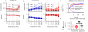

In [783]:
lo.append_figure_to_layer(lo.figures['fig5A'], 'A1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig5B'], 'B1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig5C'], 'C1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig5D'], 'D1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig5E'], 'E1', cleartarget=True)

lo.write_svg('fig5_template.svg')
display(SVG('fig5_template.svg'))